#📌 Extracão

In [18]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'

dados = pd.read_json(url)



In [20]:
# Remove colunas aninhadas originais e expande seus conteúdos com pd.json_normalize
dados_normalizados = pd.concat([
    dados.drop(columns=['customer', 'phone', 'internet', 'account']),
    pd.json_normalize(dados['customer']),
    pd.json_normalize(dados['phone']),
    pd.json_normalize(dados['internet']),
    pd.json_normalize(dados['account'])
], axis=1)

# Exibe as primeiras linhas do novo DataFrame consolidado
dados_normalizados.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [21]:
# Renomeia os cabeçalhos das colunas traduzindo para português
dados_normalizados = dados_normalizados.rename(columns={
    'customerID': 'ID_Cliente',
    'Churn': 'Cancelou',
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Conjuge',
    'Dependents': 'Dependentes',
    'tenure': 'Permanencia',
    'PhoneService': 'Servico_Telefone',
    'MultipleLines': 'Multiplas_Linhas',
    'InternetService': 'Tipo_Internet',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Protecao_Dispositivo',
    'TechSupport': 'Suporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Filmes',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Fatura_Digital',
    'PaymentMethod': 'Metodo_Pagamento',
    'Charges.Monthly': 'Cobranca_Mensal',
    'Charges.Total': 'Cobranca_Total'
})

In [22]:
dados_normalizados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_Cliente            7267 non-null   object 
 1   Cancelou              7267 non-null   object 
 2   Genero                7267 non-null   object 
 3   Idoso                 7267 non-null   int64  
 4   Conjuge               7267 non-null   object 
 5   Dependentes           7267 non-null   object 
 6   Permanencia           7267 non-null   int64  
 7   Servico_Telefone      7267 non-null   object 
 8   Multiplas_Linhas      7267 non-null   object 
 9   Tipo_Internet         7267 non-null   object 
 10  OnlineSecurity        7267 non-null   object 
 11  Backup_Online         7267 non-null   object 
 12  Protecao_Dispositivo  7267 non-null   object 
 13  Suporte_Tecnico       7267 non-null   object 
 14  Streaming_TV          7267 non-null   object 
 15  Streaming_Filmes     

In [23]:
# Verifica se há duplicatas na coluna 'ID_Cliente'
dados_normalizados.ID_Cliente.duplicated()

,ID_Cliente
0,False
1,False
2,False
3,False
4,False
...,...
7262,False
7263,False
7264,False
7265,False


In [24]:
# Converte colunas originalmente do tipo texto ('object') para tipo numérico
colunas_transformadas = ['Permanencia', 'Cobranca_Mensal', 'Cobranca_Total']

dados_normalizados[colunas_transformadas] = dados_normalizados[colunas_transformadas].apply(pd.to_numeric, errors='coerce')

# Exibe os tipos de dados atualizados das colunas do DataFrame
dados_normalizados.dtypes

,0
ID_Cliente,object
Cancelou,object
Genero,object
Idoso,int64
Conjuge,object
Dependentes,object
Permanencia,int64
Servico_Telefone,object
Multiplas_Linhas,object
Tipo_Internet,object


In [25]:
# Verifica a quantidade de valores nulos (NaN) em cada coluna do DataFrame
dados_normalizados.isnull().sum()


,0
ID_Cliente,0
Cancelou,0
Genero,0
Idoso,0
Conjuge,0
Dependentes,0
Permanencia,0
Servico_Telefone,0
Multiplas_Linhas,0
Tipo_Internet,0


In [27]:
dados_normalizados[dados_normalizados['Cobranca_Total'].isnull()]

dados_normalizados['Cobranca_Total'] = dados_normalizados['Cobranca_Total'].fillna(0)

dados_normalizados['Cancelou'] = dados_normalizados['Cancelou']


#🔧 Transformação

In [28]:
# Cria uma coluna com o valor diário estimado a partir da cobrança mensal
dados_normalizados['Cobranca_diaria_(valorMensal)'] = round(dados_normalizados['Cobranca_Mensal'] / 30, 2)

# Cria uma coluna com o valor diário estimado a partir da cobrança total e tempo de permanência
dados_normalizados['Cobranca_diaria_(valorTotal)'] = round(dados_normalizados['Cobranca_Total'] / dados_normalizados['Permanencia'] / 30, 2)

# Exibe as primeiras linhas do DataFrame atualizado
dados_normalizados.head()

,ID_Cliente,Cancelou,Genero,Idoso,Conjuge,Dependentes,Permanencia,Servico_Telefone,Multiplas_Linhas,Tipo_Internet,...,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Total,Cobranca_diaria_(valorMensal),Cobranca_diaria_(valorTotal)
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19,2.20
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00,2.01
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46,2.34
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27,3.17
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80,2.97


In [30]:

dados_normalizados.query("Permanencia == 12")

,ID_Cliente,Cancelou,Genero,Idoso,Conjuge,Dependentes,Permanencia,Servico_Telefone,Multiplas_Linhas,Tipo_Internet,...,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Total,Cobranca_diaria_(valorMensal),Cobranca_diaria_(valorTotal)
39,0064-SUDOG,No,Female,0,Yes,Yes,12,Yes,No,No,...,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),20.30,224.50,0.68,0.62
86,0135-NMXAP,Yes,Female,0,No,No,12,Yes,Yes,Fiber optic,...,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),89.75,1052.40,2.99,2.92
124,0208-BPQEJ,No,Female,0,Yes,Yes,12,Yes,No,No,...,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),19.40,198.10,0.65,0.55
181,0282-NVSJS,No,Female,1,Yes,Yes,12,No,No phone service,DSL,...,Yes,No,No,Month-to-month,Yes,Mailed check,29.30,355.90,0.98,0.99
381,0547-HURJB,No,Male,0,No,Yes,12,Yes,No,No,...,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),21.05,235.80,0.70,0.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6809,9391-EOYLI,Yes,Male,1,Yes,No,12,Yes,No,Fiber optic,...,No,No,Yes,Month-to-month,Yes,Electronic check,80.45,950.20,2.68,2.64
6854,9456-ETVCM,,Male,0,No,No,12,Yes,Yes,Fiber optic,...,No,Yes,Yes,Month-to-month,No,Electronic check,94.55,1173.55,3.15,3.26
7131,9817-APLHW,No,Male,0,No,No,12,Yes,Yes,No,...,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,25.00,316.20,0.83,0.88
7152,9837-FWLCH,No,Male,0,Yes,Yes,12,Yes,No,No,...,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,19.20,239.00,0.64,0.66


#📊 Carga e análise

In [31]:


dados_normalizados.describe()

,Idoso,Permanencia,Cobranca_Mensal,Cobranca_Total,Cobranca_diaria_(valorMensal),Cobranca_diaria_(valorTotal)
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.162653,32.346498,64.720098,2277.182035,2.157292,2.158461
std,0.369074,24.571773,30.129572,2268.648587,1.004407,1.007454
min,0.000000,0.000000,18.250000,0.000000,0.610000,0.460000
25%,0.000000,9.000000,35.425000,396.200000,1.180000,1.190000
50%,0.000000,29.000000,70.300000,1389.200000,2.340000,2.340000
75%,0.000000,55.000000,89.875000,3778.525000,2.995000,3.010000
max,1.000000,72.000000,118.750000,8684.800000,3.960000,4.050000


In [34]:

dados_Idosos = dados_normalizados.query('Idoso == 1')
dados_Nao_Idosos = dados_normalizados.query('Idoso == 0')

print('Dados Idosas ')
dados_Idosos[['Permanencia', 'Cobranca_Mensal', 'Cobranca_Total']].mean()

 Dados de pessoas Idosas 


,0
Permanencia,33.360406
Cobranca_Mensal,79.785195
Cobranca_Total,2812.864848


In [35]:
print('Dados Não Idosos')

dados_Nao_Idosos[['Permanencia', 'Cobranca_Mensal', 'Cobranca_Total']].mean()

Dados Não Idosos


,0
Permanencia,32.149548
Cobranca_Mensal,61.793730
Cobranca_Total,2173.126639


In [40]:
# Calculando o número total de clientes idosos e nao idosos
numero_idosos = dados_Idosos['Idoso'].sum()
numero_nao_idosos = quantidade_Nao_idosos = dados_normalizados.query('Idoso == 0').shape[0]

# Soma o total de clientes (idosos + não idosos)
total = numero_idosos + numero_nao_idosos

# Calcula o número de idosos que continuam como clientes ativos
idosos_permanentes = dados_normalizados.query('Idoso == 1 & Cancelou == "No"').shape[0]

# Exibe os resultados da análise por faixa etária
print(f'Numero de Idosos é de : {numero_idosos}, e o numero de Não Idosos é de: {numero_nao_idosos}')
print('\n')
print(f'A proporção do numero de Idosos é de : {numero_idosos / total:.2%}')
print('\n')
print(f'Numero de Idosos que ainda permanecem é de {idosos_permanentes}, e é de proporção de {idosos_permanentes / total:.2%}')


Numero de Idosos é de : 1182, e o numero de Não Idosos é de: 6085


A proporção do numero de Idosos é de : 16.27%


Numero de Idosos que ainda permanecem é de 666, e é de proporção de 9.16%


In [41]:
Clientes_total = dados_normalizados.query('Cancelou == "No"').shape[0]

Clientes_nao_Idosos = Clientes_total - idosos_permanentes

Clientes_Cancelados = dados_normalizados.query('Cancelou == "Yes"').shape[0]

print(f'Clientes totais: {Clientes_total} \n Clientes não idosos: {Clientes_nao_Idosos}, \n Total de Clientes Cancelados: {Clientes_Cancelados}. \n Proporção de Cancelamento {Clientes_Cancelados / Clientes_total:.2%}')


Clientes totais: 5174 
 Clientes não idosos: 4508, 
 Total de Clientes Cancelados: 1869. 
 Proporção de Cancelamento 36.12%


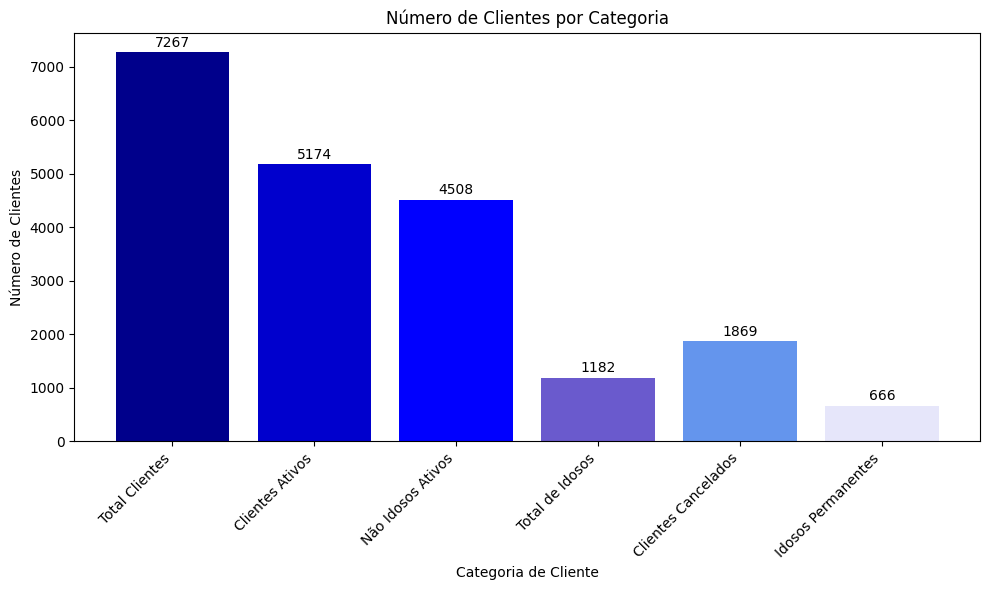

In [45]:
# Define os rótulos das categorias que serão exibidas no gráfico
labels = ['Total Clientes', 'Clientes Ativos', 'Não Idosos Ativos', 'Total de Idosos', 'Clientes Cancelados', 'Idosos Permanentes']

# Define os valores correspondentes a cada categoria com base nas variáveis previamente calculadas
# Certifique-se de que todas essas variáveis foram definidas anteriormente
values = [total, Clientes_total, Clientes_nao_Idosos, numero_idosos, Clientes_Cancelados, idosos_permanentes]

# Inicializa o gráfico de barras e define o tamanho da figura
plt.figure(figsize=(10, 6))
plt.bar(labels, values, color=['darkblue', 'mediumblue', 'blue', 'slateblue', 'cornflowerblue', 'lavender'])

# Define o título do gráfico e os rótulos dos eixos
plt.title('Número de Clientes por Categoria')
plt.xlabel('Categoria de Cliente')
plt.ylabel('Número de Clientes')

# Rotaciona os rótulos do eixo x para facilitar a leitura
plt.xticks(rotation=45, ha='right')

# Exibe os valores numéricos acima de cada barra
for i, value in enumerate(values):
    plt.text(i, value + 50, str(value), ha='center', va='bottom')

# Ajusta o layout para evitar cortes ou sobreposição de elementos
plt.tight_layout()

# Exibe o gráfico
plt.show()

In [48]:
clientes_homens_ativos = dados_normalizados.query('Genero == "Male" & Cancelou == "No"').shape[0]
clientes_mulheres_ativas = dados_normalizados.query('Genero == "Female" & Cancelou == "No"').shape[0]
clientes_homens_cancelados = dados_normalizados.query('Genero == "Male" & Cancelou == "Yes"').shape[0]
clientes_mulheres_canceladas = dados_normalizados.query('Genero == "Female" & Cancelou == "Yes"').shape[0]

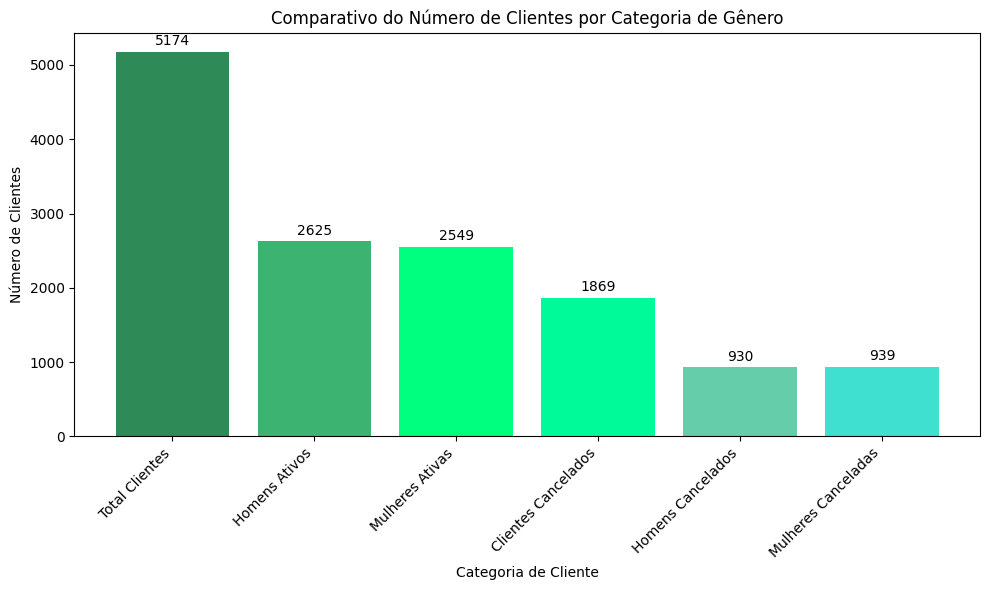

In [50]:

labels = ['Total Clientes', 'Homens Ativos', 'Mulheres Ativas', 'Clientes Cancelados', 'Homens Cancelados', "Mulheres Canceladas"  ]

# Define os valores para cada categoria com base nas variáveis previamente calculadas
# Certifique-se de que todas essas variáveis foram definidas anteriormente
values = [ Clientes_total, clientes_homens_ativos, clientes_mulheres_ativas, Clientes_Cancelados, clientes_homens_cancelados, clientes_mulheres_canceladas ]

# Inicializa o gráfico de barras e define o tamanho da figura
plt.figure(figsize=(10, 6))
plt.bar(labels, values, color=['seagreen', 'mediumseagreen', 'springgreen', 'mediumspringgreen', 'mediumaquamarine', 'turquoise'])

# Define o título e os rótulos dos eixos
plt.title('Comparativo do Número de Clientes por Categoria de Gênero')
plt.xlabel('Categoria de Cliente')
plt.ylabel('Número de Clientes')

# Rotaciona os rótulos do eixo x para facilitar a leitura, se necessário
plt.xticks(rotation=45, ha='right')

# Exibe os valores numéricos acima de cada barra
for i, value in enumerate(values):
    plt.text(i, value + 50, str(value), ha='center', va='bottom')

# Ajusta o layout para evitar sobreposição ou cortes nos elementos
plt.tight_layout()

# Renderiza o gráfico
plt.show()

#📄Relatorio Final

O objetivo da análise foi feito para tratamento e limpeza de dados para entender o probema de Churn da empresa